In [ ]:
import pandas as pd

# Veriyi oku
df = pd.read_csv('diabetes.csv')

# 1. Verinin ilk 5 satırına bak (Genel bir bakış)
print("--- Verinin İlk 5 Satırı ---")
print(df.head())

--- Verinin İlk 5 Satırı ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
# 2. Veri tiplerini ve boş (null) değer olup olmadığını kontrol et
print("\n--- Veri Bilgisi ---")
print(df.info())


--- Veri Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
# 3. İstatistiksel özet (En küçük, en büyük ve ortalama değerler)
print("\n--- İstatistiksel Özet ---")
print(df.describe())


--- İstatistiksel Özet ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min    

In [ ]:
gizli_eksik_sutunlar = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [ ]:
# Her sütundaki 0 sayısını hesapla
for sutun in gizli_eksik_sutunlar:
    sifir_sayisi = (df[sutun] == 0).sum()
    print(f"{sutun} sütunundaki gizli eksik (0) sayısı: {sifir_sayisi}")

Glucose sütunundaki gizli eksik (0) sayısı: 5
BloodPressure sütunundaki gizli eksik (0) sayısı: 35
SkinThickness sütunundaki gizli eksik (0) sayısı: 227
Insulin sütunundaki gizli eksik (0) sayısı: 374
BMI sütunundaki gizli eksik (0) sayısı: 11


In [ ]:
import numpy as np

# 1. Adım: 0 değerlerini gerçek "Eksik Değer" (NaN) sembolüyle değiştir
# (Pregnancies ve Outcome sütunlarına dokunmuyoruz, onlar 0 olabilir)
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

# 2. Adım: Her sütundaki boşlukları o sütunun MEDYAN değeriyle doldur
for sutun in cols_to_fix:
    medyan_degeri = df[sutun].median()
    df[sutun] = df[sutun].fillna(medyan_degeri)

# 3. Adım: Kontrol et (Artık hiçbirinde 0 kalmamış olmalı)
print("--- Doldurma İşlemi Sonrası Minimum Değerler ---")
print(df[cols_to_fix].min())

--- Doldurma İşlemi Sonrası Minimum Değerler ---
Glucose          44.0
BloodPressure    24.0
SkinThickness     7.0
Insulin          14.0
BMI              18.2
dtype: float64


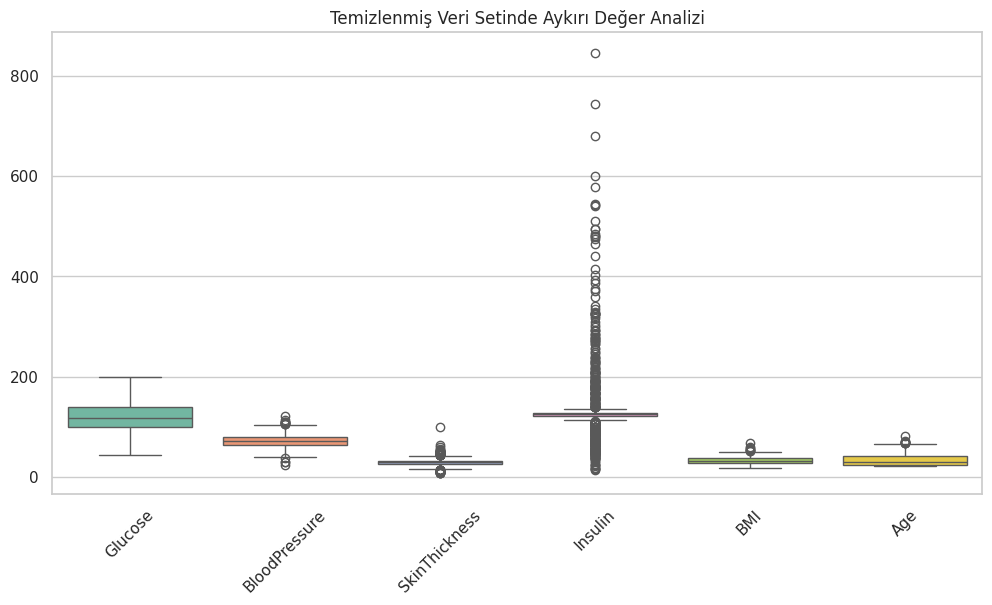

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik stilini ayarla
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# Boxplot (Kutu Grafiği) oluştur
# Temizlediğimiz sütunları ve Yaş sütununu inceleyelim
sns.boxplot(data=df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']], palette="Set2")

plt.title('Temizlenmiş Veri Setinde Aykırı Değer Analizi')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Ölçekleyiciyi tanımla
scaler = MinMaxScaler()

# 2. 'Outcome' (hedef) dışındaki tüm sütunları seç ve ölçeklendir
# Hedef sütunu (0 veya 1) olduğu gibi kalmalı.
ozellikler = df.columns.drop('Outcome')
df[ozellikler] = scaler.fit_transform(df[ozellikler])

# 3. İlk 5 satıra bak (Artık her şey 0.12, 0.45 gibi görünecek)
print("--- Normalizasyon Sonrası Veriler ---")
print(df.head())

--- Normalizasyon Sonrası Veriler ---
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.352941  0.670968       0.489796       0.304348  0.133413  0.314928   
1     0.058824  0.264516       0.428571       0.239130  0.133413  0.171779   
2     0.470588  0.896774       0.408163       0.239130  0.133413  0.104294   
3     0.058824  0.290323       0.428571       0.173913  0.096154  0.202454   
4     0.000000  0.600000       0.163265       0.304348  0.185096  0.509202   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.234415  0.483333        1  
1                  0.116567  0.166667        0  
2                  0.253629  0.183333        1  
3                  0.038002  0.000000        0  
4                  0.943638  0.200000        1  


In [ ]:
# Hangi sınıftan kaç tane var?
print("--- Sınıf Dağılımı ---")
print(df['Outcome'].value_counts())

# Yüzdesel oran
print("\n--- Yüzdesel Dağılım ---")
print(df['Outcome'].value_counts(normalize=True) * 100)

--- Sınıf Dağılımı ---
Outcome
0    500
1    268
Name: count, dtype: int64

--- Yüzdesel Dağılım ---
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


/tmp/ipykernel_187/4073217830.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')


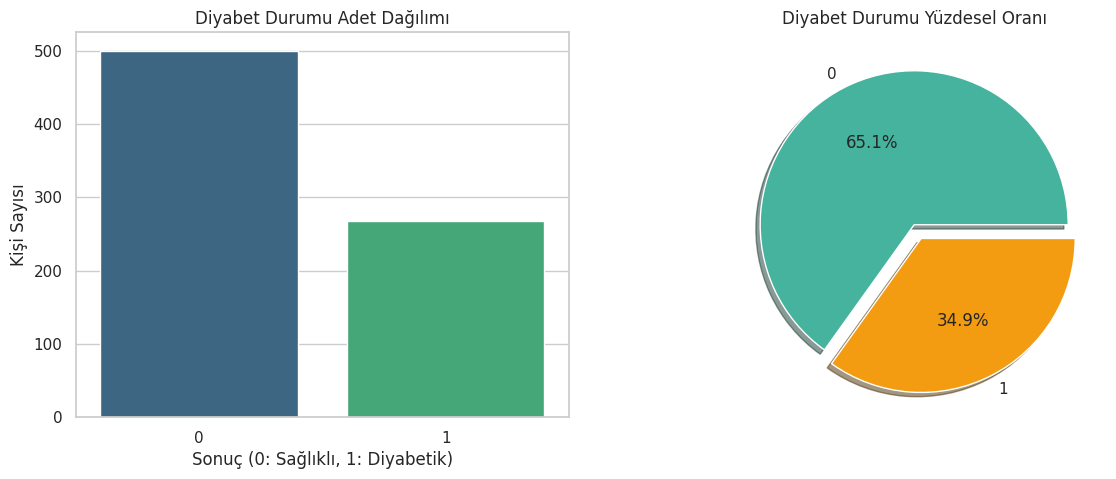

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik alanı oluştur (1 satır, 2 sütun)
plt.figure(figsize=(14, 5))

# 1. Sütun Grafiği (Adetleri görmek için)
plt.subplot(1, 2, 1)
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Diyabet Durumu Adet Dağılımı')
plt.xlabel('Sonuç (0: Sağlıklı, 1: Diyabetik)')
plt.ylabel('Kişi Sayısı')

# 2. Pasta Grafiği (Yüzdesel oranı görmek için)
plt.subplot(1, 2, 2)
df['Outcome'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', shadow=True, colors=['#45B39D', '#F39C12'])
plt.title('Diyabet Durumu Yüzdesel Oranı')
plt.ylabel('') # Y ekseni etiketini temizle

plt.show()

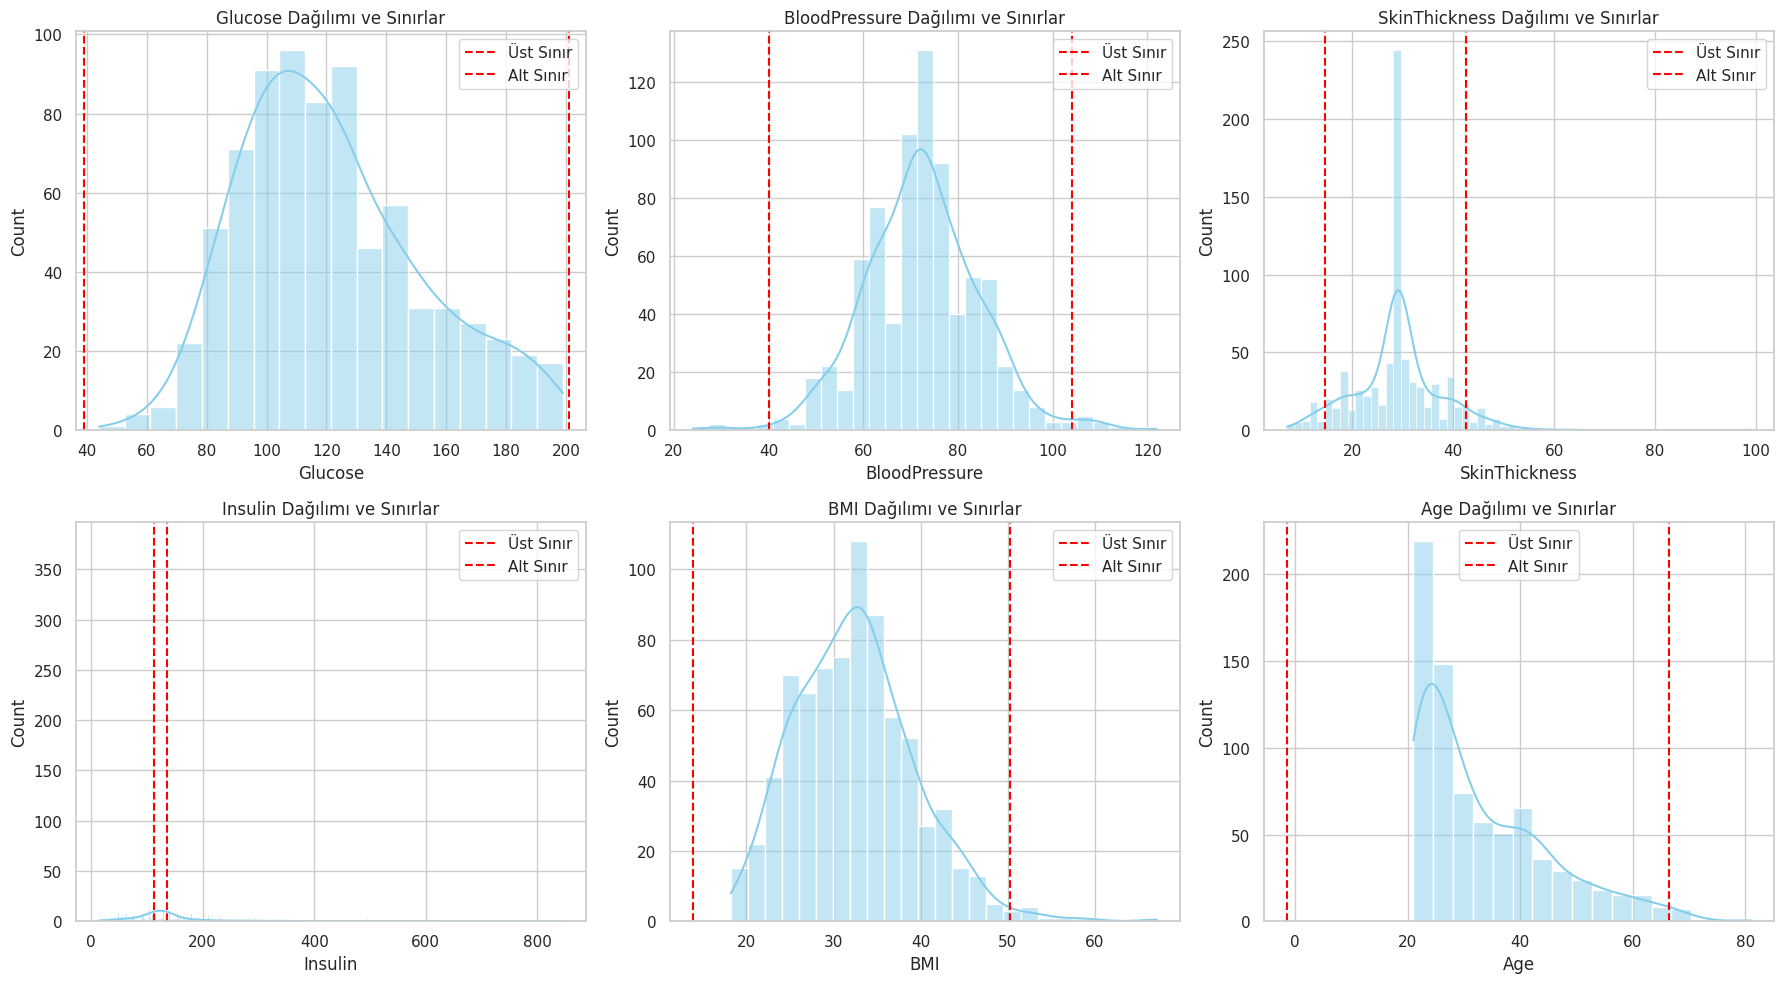

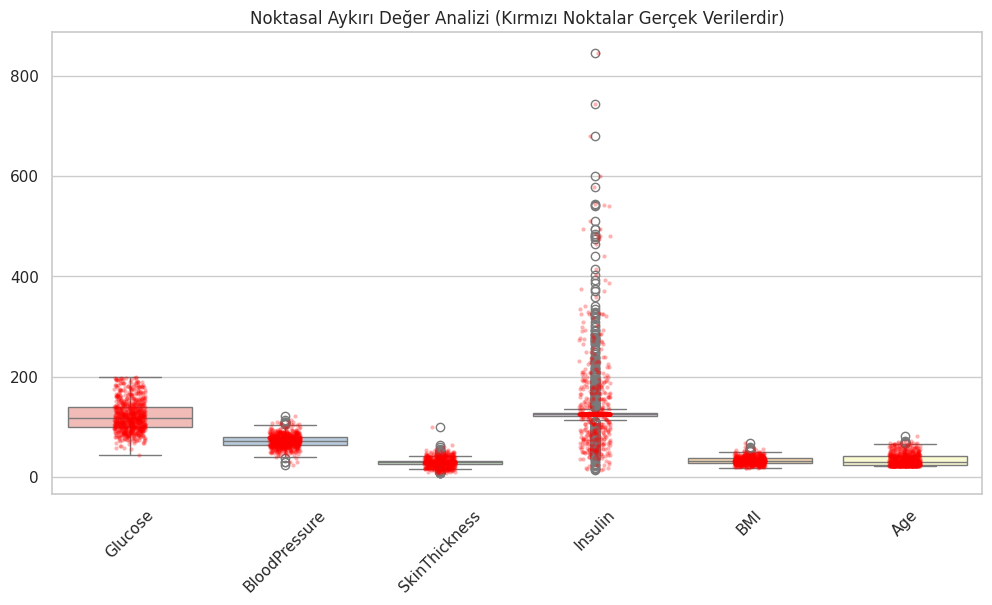

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Veriyi Yükleme ve Önceki Adımları Uygulama (Median Imputation)
df = pd.read_csv('diabetes.csv')
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)
for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

# 2. Aykırı Değerleri Sınırlarıyla Görselleştirme
# Her özellik için dağılım grafiği ve IQR sınırlarını çiziyoruz
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()
viz_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

for i, col in enumerate(viz_cols):
    # IQR Hesabı (Matematiksel Sınırlar)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    ust_sinir = Q3 + 1.5 * IQR
    alt_sinir = Q1 - 1.5 * IQR

    # Dağılım (Histogram) çizimi
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')

    # Sınırları kırmızı kesikli çizgiyle gösteriyoruz
    axes[i].axvline(ust_sinir, color='red', linestyle='--', label='Üst Sınır')
    axes[i].axvline(alt_sinir, color='red', linestyle='--', label='Alt Sınır')
    axes[i].set_title(f'{col} Dağılımı ve Sınırlar')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 3. Detaylı Bakış: Boxplot + Stripplot (Her veriyi nokta olarak gör)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[viz_cols], palette='Pastel1')
# Her bir gerçek veriyi kırmızı küçük birer nokta olarak üzerine ekliyoruz
sns.stripplot(data=df[viz_cols], color='red', size=3, alpha=0.3)
plt.title('Noktasal Aykırı Değer Analizi (Kırmızı Noktalar Gerçek Verilerdir)')
plt.xticks(rotation=45)
plt.show()

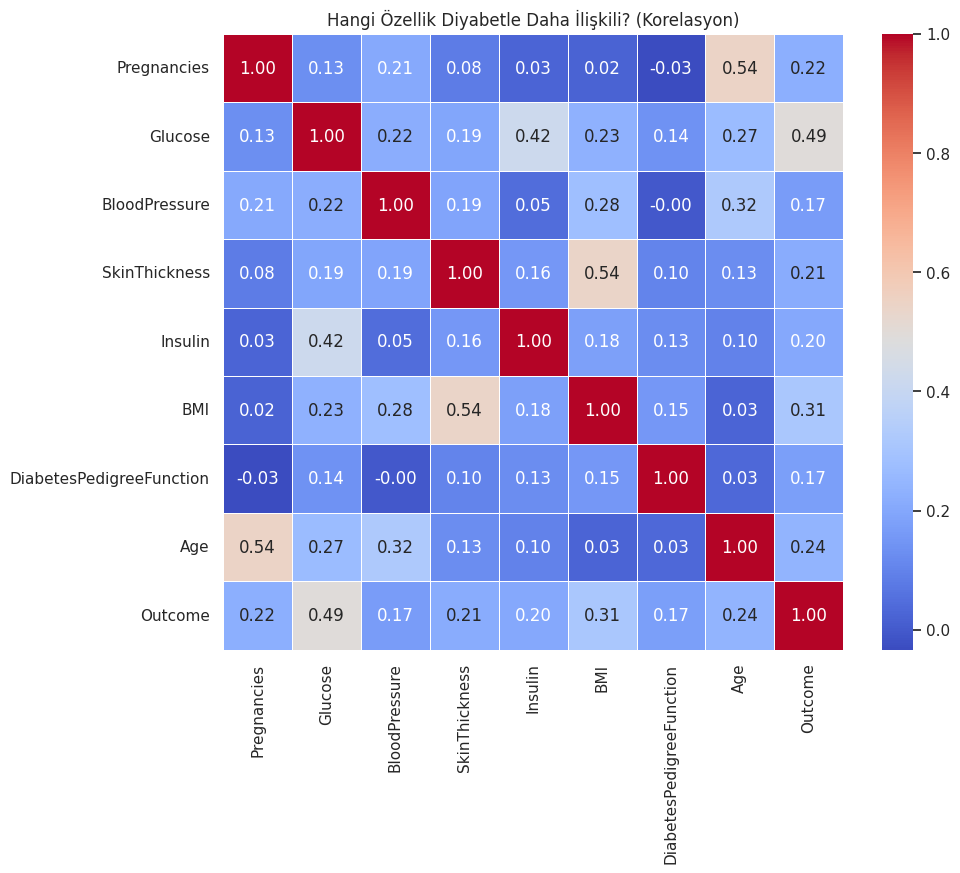

/tmp/ipykernel_187/1155505413.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='Glucose', data=df, palette="muted", split=True)
/tmp/ipykernel_187/1155505413.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='BMI', data=df, palette="magma", split=True)


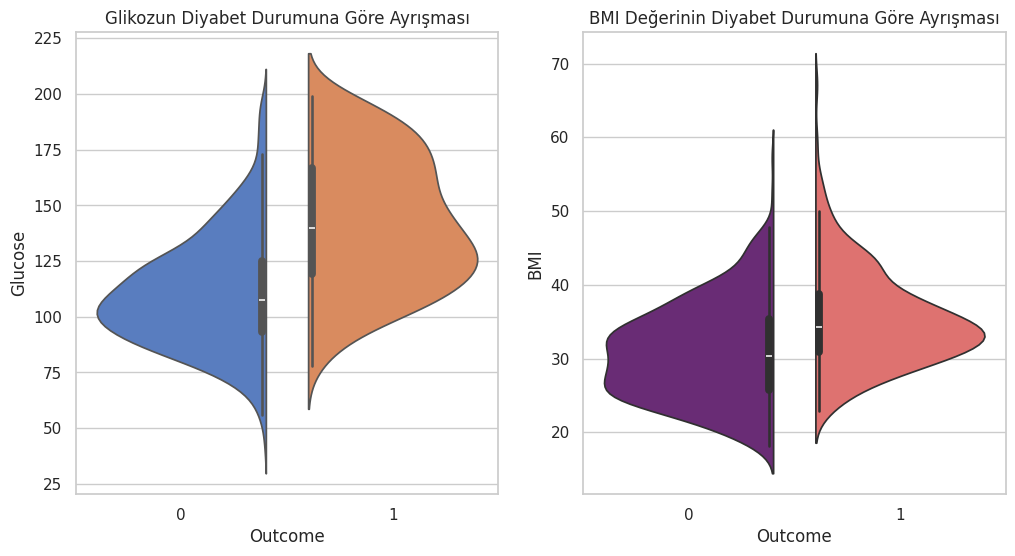

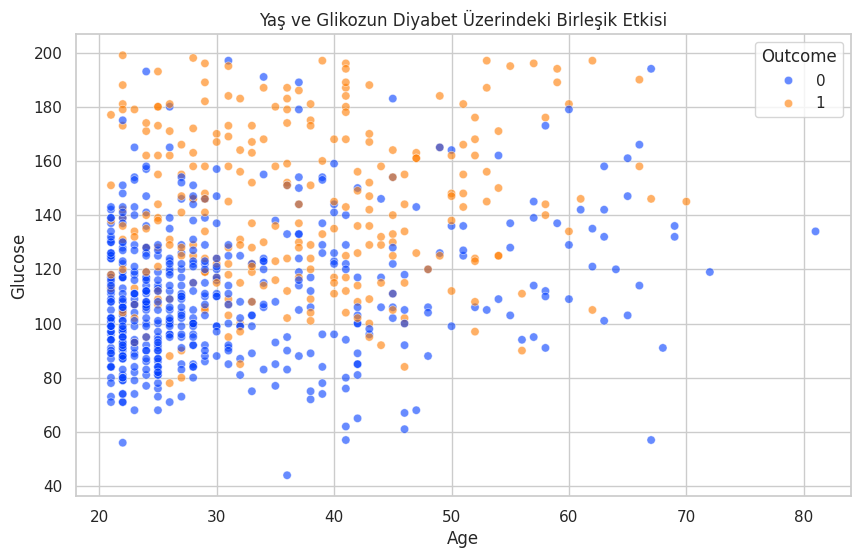

In [ ]:
# --- EKSİK 1: Isı Haritası (Heatmap) ---
plt.figure(figsize=(10, 8))
# df.corr() ile sütunlar arası matematiksel bağı hesaplıyoruz [cite: 1690]
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Hangi Özellik Diyabetle Daha İlişkili? (Korelasyon)')
plt.show()

# --- EKSİK 2: Kritik Özelliklerin Ayrışması (Violin Plot) ---
# Keman grafiği hem dağılımı hem de medyanı Outcome'a göre ayırarak gösterir.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.violinplot(x='Outcome', y='Glucose', data=df, palette="muted", split=True)
plt.title('Glikozun Diyabet Durumuna Göre Ayrışması')

plt.subplot(1, 2, 2)
sns.violinplot(x='Outcome', y='BMI', data=df, palette="magma", split=True)
plt.title('BMI Değerinin Diyabet Durumuna Göre Ayrışması')
plt.show()

# --- EKSİK 3: Yaş ve Kan Şekeri İlişkisi (Scatter Plot) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Glucose', hue='Outcome', data=df, alpha=0.6, palette='bright')
plt.title('Yaş ve Glikozun Diyabet Üzerindeki Birleşik Etkisi')
plt.show()

In [ ]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


/tmp/ipykernel_187/909753326.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='Glucose_BMI_Risk', data=df, palette='spring', split=True)


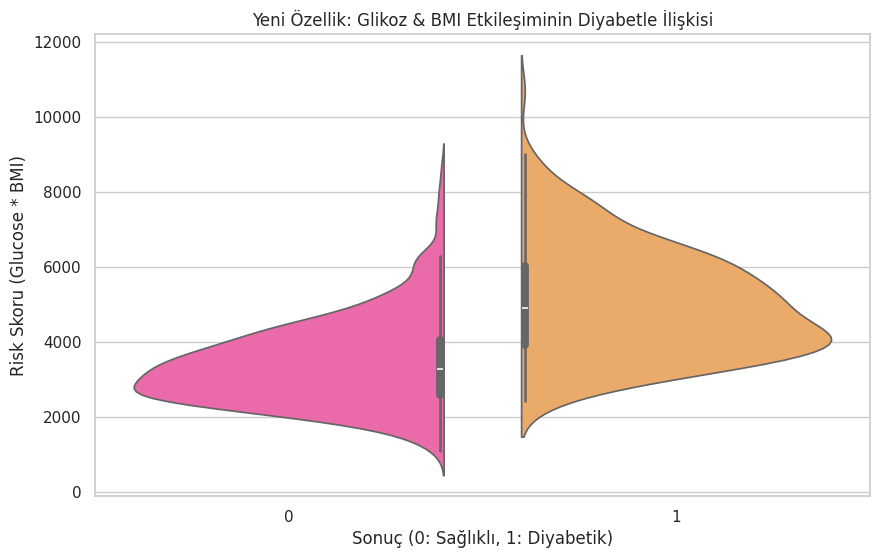

Yeni oluşturduğumuz 'Glucose_BMI_Risk' sütununun diyabetle korelasyonu: 0.5199


In [ ]:
# 1. Yeni özelliği oluştur (Glikoz ve BMI çarpımı)
# Bu işlem, her iki değeri de yüksek olan kişilerin riskini "katlayarak" gösterir.
df['Glucose_BMI_Risk'] = df['Glucose'] * df['BMI']

# 2. Yeni özelliğin diyabetle ilişkisini görselleştir (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(x='Outcome', y='Glucose_BMI_Risk', data=df, palette='spring', split=True)

plt.title('Yeni Özellik: Glikoz & BMI Etkileşiminin Diyabetle İlişkisi')
plt.xlabel('Sonuç (0: Sağlıklı, 1: Diyabetik)')
plt.ylabel('Risk Skoru (Glucose * BMI)')
plt.show()

# 3. Korelasyonu kontrol et (Yeni özelliğimiz ne kadar güçlü?)
yeni_korelasyon = df.corr()['Outcome']['Glucose_BMI_Risk']
print(f"Yeni oluşturduğumuz 'Glucose_BMI_Risk' sütununun diyabetle korelasyonu: {yeni_korelasyon:.4f}")

In [ ]:
# Yeni sütunu da 0-1 arasına çekelim
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Glucose_BMI_Risk']] = scaler.fit_transform(df[['Glucose_BMI_Risk']])